<a href="https://colab.research.google.com/github/miss-dd/Team--IOTA/blob/main/Team_Success.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# House Price Prediction Using Linear Regression

## Introduction

This project applies a Linear Regression model to predict house prices using the Ames Housing dataset. The dataset contains information about 1,460 houses, including features such as the size of the house, overall quality, number of rooms, and year built.

The objective of this assignment is to build a machine learning model that predicts the selling price (`SalePrice`) of a house based on selected features. Before training the model, the dataset is cleaned by handling missing values and converting categorical variables into numerical form where necessary.

The model is then evaluated using standard performance metrics such as Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), and the R² score to determine how accurately it predicts house prices.

Importing libraries


In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
from google.colab import files

uploaded = files.upload('train.csv')

Saving train.csv to train.csv/train (1).csv


Load train dataset

In [ ]:
df = pd.read_csv('train.csv/train.csv')


## Dataset Preview

The first five rows were displayed to make sure the dataset loaded correctly. This also gives a quick idea of the available features and the format of the data. The dataset contains information about different houses, including their size, quality, location, and selling price.

Display first 5 rows of the dataset



In [ ]:
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [ ]:
X = df.drop('SalePrice', axis=1)
y = df['SalePrice']

## Dataset Shape

The dataset contains 1,460 house records and 81 columns. One column represents the target variable, `SalePrice`, while the remaining columns contain information that can be used to predict house prices.

In [ ]:
print(df.shape)

(1460, 81)


## Data Types

The dataset contains both numerical and categorical variables. Numerical variables include values such as house size and number of rooms, while categorical variables describe characteristics such as neighborhood or roof type. Understanding the data types helps determine the appropriate preprocessing steps.

In [ ]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

## Missing Values

Some features contain missing values. Instead of removing those records, the missing numerical values were replaced with the median, while missing categorical values were replaced with the most common category. This keeps as much useful information as possible without introducing unnecessary bias.

In [ ]:
missing = df.isnull().sum()
print(missing[missing > 0])

LotFrontage      259
Alley           1369
MasVnrType       872
MasVnrArea         8
BsmtQual          37
BsmtCond          37
BsmtExposure      38
BsmtFinType1      37
BsmtFinType2      38
Electrical         1
FireplaceQu      690
GarageType        81
GarageYrBlt       81
GarageFinish      81
GarageQual        81
GarageCond        81
PoolQC          1453
Fence           1179
MiscFeature     1406
dtype: int64


In [ ]:
X = df.drop('SalePrice', axis=1)
y = df['SalePrice']

Count missing values


In [ ]:
missing = df.isnull().sum()
print(missing[missing > 0])

LotFrontage      259
Alley           1369
MasVnrType       872
MasVnrArea         8
BsmtQual          37
BsmtCond          37
BsmtExposure      38
BsmtFinType1      37
BsmtFinType2      38
Electrical         1
FireplaceQu      690
GarageType        81
GarageYrBlt       81
GarageFinish      81
GarageQual        81
GarageCond        81
PoolQC          1453
Fence           1179
MiscFeature     1406
dtype: int64


## Feature Engineering

Before training the model, the data was prepared for machine learning. Categorical variables were converted into numerical values using one hot encoding, and missing values were handled. These preprocessing steps ensure that the model can learn from every feature.

In [ ]:
# Numerical columns
X = X.fillna(X.median(numeric_only=True))

# Categorical columns
X = X.fillna("None")

In [ ]:
df = pd.get_dummies(df, drop_first=True)
print(df.shape)

(1460, 246)


In [ ]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Columns: 246 entries, Id to SaleCondition_Partial
dtypes: bool(208), float64(3), int64(35)
memory usage: 730.1 KB
None


## Feature Selection

Only six important features were selected for training the model. Using a smaller number of meaningful features reduces complexity while still allowing the model to capture the major factors that influence house prices.

In [ ]:
features = ['OverallQual',
            'GrLivArea',
            'GarageCars',
            'TotalBsmtSF',
            'FullBath',
            'YearBuilt']
X = df[features]
y = df['SalePrice']

## Train Test Split

The dataset was divided into training and testing sets. The training set was used to teach the model, while the testing set was kept aside to evaluate how well the model performs on unseen data.

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
print(X.shape)
print(y.shape)

(1460, 6)
(1460,)


## Model Training

A Linear Regression model was trained after standardizing the selected features. Standardization places all features on a similar scale, allowing the model to learn more effectively.

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler

# Scale features
scaler = StandardScaler()

X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

# Train the model
model = LinearRegression()
model.fit(X_train_s, y_train)

# Predict on test set
y_pred = model.predict(X_test_s)

print("Training complete!")

Training complete!


## Model Evaluation

The model was evaluated using RMSE, MAE, and R² score. These metrics provide different perspectives on prediction accuracy and help determine how well the model fits the data.

In [ ]:
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

mse = mean_squared_error(y_test, y_pred)

rmse = np.sqrt(mse)

mae = mean_absolute_error(y_test, y_pred)

r2 = r2_score(y_test, y_pred)

print(f"RMSE: ${rmse:,.0f}")
print(f"MAE : ${mae:,.0f}")
print(f"R2  : {r2:.4f}")

RMSE: $39,711
MAE : $25,320
R2  : 0.7944


## Results

The model produced the following results:

RMSE: $39,711

MAE: $25,320

R² Score: 0.7944

The RMSE shows that the model's predictions differ from the actual house prices by about $39,700 on average. Since RMSE gives more weight to larger errors, it suggests that some expensive houses are more difficult to predict accurately.

The MAE indicates that the average prediction error is about $25,300. This means that, on average, the predicted selling price is within roughly twenty five thousand dollars of the actual price.

The R² score of 0.7944 means that the model explains about 79 percent of the variation in house prices. This is a good result for a simple Linear Regression model and suggests that the selected features capture most of the important information needed for prediction.

visualize result

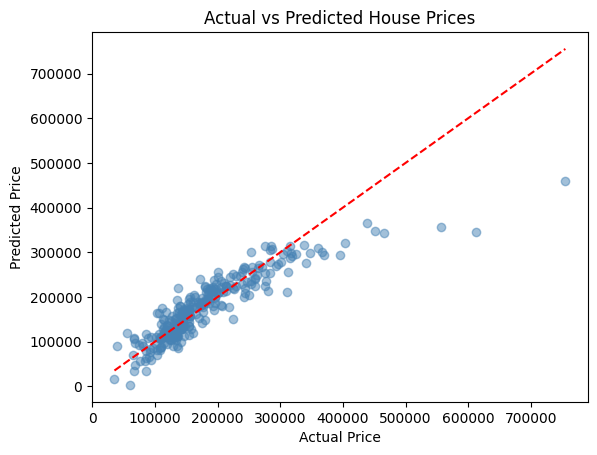

In [ ]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred, alpha=0.5, color='steelblue')

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)

plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Actual vs Predicted House Prices')

plt.show()

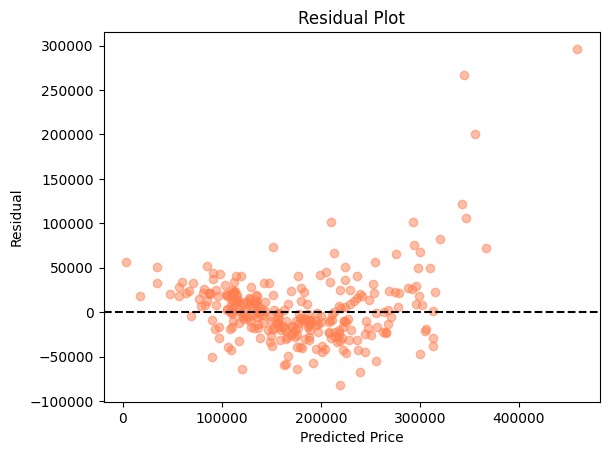

In [ ]:
import matplotlib.pyplot as plt

# Calculate residuals
residuals = y_test - y_pred

# Plot residuals
plt.scatter(
    y_pred,
    residuals,
    alpha=0.5,
    color='coral'
)

# Zero error reference line
plt.axhline(
    0,
    color='black',
    linestyle='--'
)

plt.xlabel('Predicted Price')
plt.ylabel('Residual')
plt.title('Residual Plot')

plt.show()

## Residual Analysis

The residual plot shows the difference between the actual and predicted prices. Most residuals are scattered around zero without a clear pattern, which suggests that the model fits the data reasonably well. A few larger residuals are visible, showing that some houses were more difficult for the model to predict accurately.

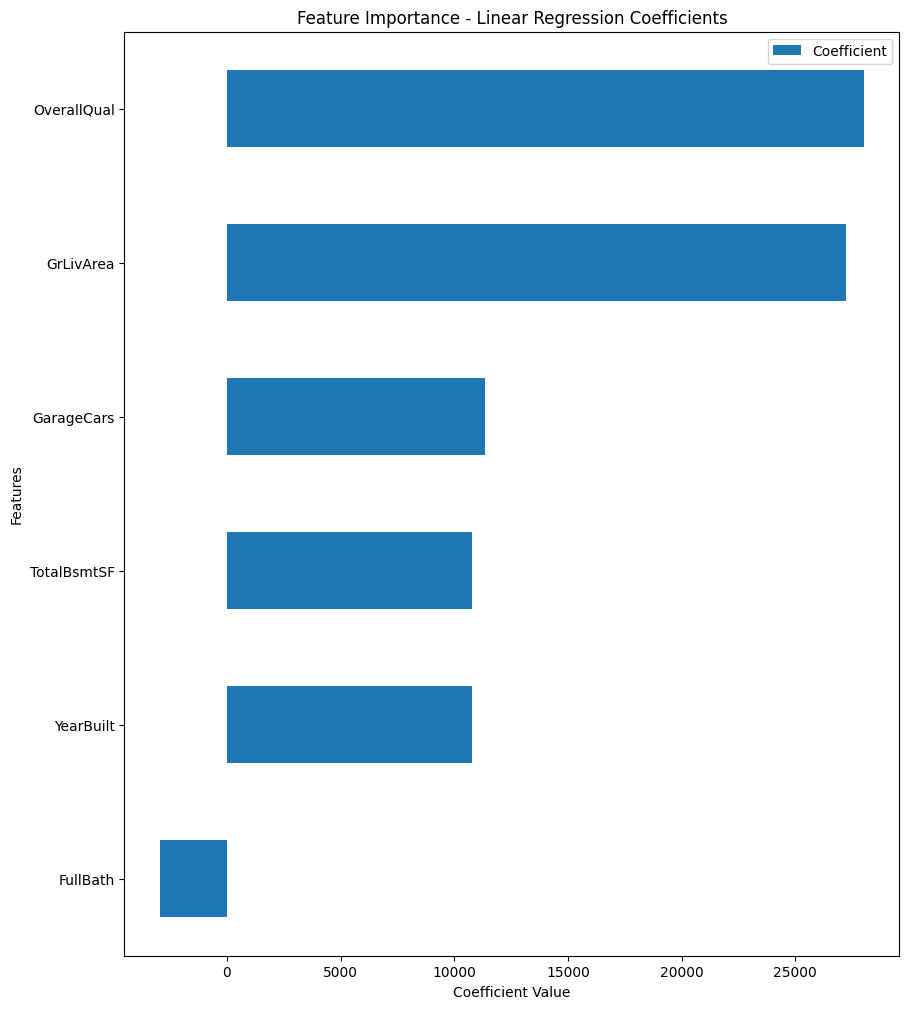

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Create dataframe of features and their coefficients
coef_df = pd.DataFrame({
    'Feature': features,
    'Coefficient': model.coef_
}).sort_values('Coefficient')

# Plot coefficients
coef_df.plot.barh(
    x='Feature',
    y='Coefficient',
    figsize=(10, 12)
)

plt.title('Feature Importance - Linear Regression Coefficients')
plt.xlabel('Coefficient Value')
plt.ylabel('Features')

plt.show()

## Feature Importance

The chart shows which features have the greatest influence on the predicted house prices. Living area and overall quality have the strongest impact, meaning that larger houses and houses with better overall quality generally sell at higher prices. The remaining features also contribute to the predictions, but their influence is smaller.

## Conclusion

This project successfully developed a Linear Regression model to predict house prices. After cleaning the data, handling missing values, encoding categorical variables, and selecting important features, the model achieved an R² score of about 79 percent. This indicates that the model explains most of the variation in house prices.

Although the model performs well, prediction errors still exist, especially for houses with extreme prices. Future improvements could include using additional features or trying more advanced machine learning models such as Random Forest, Gradient Boosting, or XGBoost to improve prediction accuracy.